# 02 — Experiment A: Model Comparison

เทียบ 5 architecture ภายใต้ setup เดียวกัน (ข้อมูล, augmentation, epoch, lr เท่ากันหมด)
แล้วเลือก 1–2 ตัวไปทำ Experiment B ต่อ

ค่าทั้งหมดอยู่ใน `configs/baseline.yaml` — แก้ที่ไฟล์นั้น ไม่ต้องแก้ในโน้ตบุ๊ก

**ก่อนรันเต็ม** แนะนำให้ทดสอบว่า pipeline เดินครบก่อนด้วย `limit_per_class` เล็ก ๆ (เซลล์ถัดไป)

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.utils.common import load_config, thai_char, save_json, RESULTS_DIR
from src.datasets.thai_chars import load_data

plt.rcParams["figure.dpi"] = 110
try:
    plt.rcParams["font.family"] = "Thonburi"   # ฟอนต์ไทยที่มากับ macOS
except Exception:
    pass
print("ROOT:", ROOT)

ROOT: /Users/thiya/Documents/GitHub/Project-1-Thai-Character-Number-Recognition


In [2]:
from src.training.run_experiment import prepare, run_model_comparison

cfg = load_config(ROOT / "configs" / "baseline.yaml")
cfg

{'img_size': 96,
 'batch_size': 128,
 'epochs': 8,
 'lr': 0.001,
 'weight_decay': 0.0001,
 'label_smoothing': 0.1,
 'pretrained': True,
 'seed': 42,
 'device': 'auto',
 'early_stop_patience': 3,
 'eval_batch_size': 256,
 'imbalance': 'none',
 'sampling_power': 0.5,
 'augmentation': 'standard',
 'models': ['custom_cnn',
  'resnet18',
  'efficientnet_b0',
  'densenet121',
  'mobilenet_v3_small'],
 'model_kwargs': {'custom_cnn': {'widths': [32, 64, 128, 256],
   'convs_per_stage': 2,
   'dropout': 0.2}},
 'split': {'type': 'random',
  'sources': 'D1',
  'val_ratio': 0.1,
  'test_ratio': 0.1},
 'model': 'resnet18',
 'hard_f1_threshold': 0.9,
 'hard_top_k': None,
 'finetune_epochs': 3,
 'finetune_lr_scale': 0.3,
 'finetune_sampling_power': 0.75,
 'limit_per_class': None}

## (ทางเลือก) ทดสอบ pipeline แบบเร็ว — ข้อมูลน้อย 1 epoch

เซลล์นี้จงใจใช้แค่ **2 โมเดล** และ 1 epoch เพื่อเช็กว่าโค้ดเดินครบเส้นทางภายในไม่กี่วินาที
ตัวเลขที่ได้ไม่มีความหมาย ส่วนหัวข้อ "รันจริง" ข้างล่างจะใช้ครบทั้ง 5 โมเดลตาม `configs/baseline.yaml`

ผลของเซลล์นี้เขียนแยกไว้ใต้ชื่อ `model_comparison_smoke` จึงไม่ทับผลรันจริง

In [3]:
smoke = dict(cfg, epochs=1, limit_per_class=8, models=["custom_cnn", "mobilenet_v3_small"],
             experiment_name="model_comparison_smoke", table_name="model_comparison_smoke")
_ = run_model_comparison(smoke)

ใช้ cache research_cache_96.npz: 163155 รูป
[limit_per_class=8] เหลือ 1729 รูป 81 คลาส
  ตัดคลาสที่มีตัวอย่างน้อยกว่า 2: 163×1, 177×1, 208×1
  [เตือน] test ตาม ratio ได้ 57 ตัวอย่าง น้อยกว่าจำนวนคลาส (73) จึงขยายเป็น 73
  [เตือน] val ตาม ratio ได้ 55 ตัวอย่าง น้อยกว่าจำนวนคลาส (73) จึงขยายเป็น 73
split: {'train': {'n': 420, 'classes': 73, 'sources': ['D1']}, 'val': {'n': 73, 'classes': 73, 'sources': ['D1']}, 'test': {'n': 73, 'classes': 73, 'sources': ['D1']}}

=== model: custom_cnn ===
[custom_cnn | aug=standard] train 420 | val 73 | 81 classes | 1.2M params | mps
    ep1 step 0/3 loss 4.5078
  epoch 1 train_loss 4.3977 train_acc 0.0130 sec 1.3830 val_acc 0.0137
  custom_cnn: acc 0.0137 | macro F1 0.0004
  ตาราง -> results/tables/model_comparison_smoke.csv

=== model: mobilenet_v3_small ===
[mobilenet_v3_small | aug=standard] train 420 | val 73 | 81 classes | 1.6M params | mps
    ep1 step 0/3 loss 4.6018
  epoch 1 train_loss 4.4872 train_acc 0.0182 sec 0.8185 val_acc 0.0000
  mobile

## รันจริง

รันครบทั้ง 5 โมเดลใน `models:` ของ config (custom_cnn, resnet18, efficientnet_b0, densenet121,
mobilenet_v3_small) × ~8 epoch บน D1 (~62,500 รูป) ใช้เวลาราว 2–4 ชั่วโมงบน Mac M-series
ผลแต่ละโมเดลเขียนลง `experiments/model_comparison/<model>/` และตารางรวมที่ `results/tables/model_comparison.csv`
(ตารางถูกเขียนใหม่ทุกครั้งที่จบโมเดลหนึ่งตัว ถ้าหยุดกลางทางก็ยังมีผลเท่าที่รันไปแล้ว)

In [4]:
data = prepare(cfg)
rows = run_model_comparison(cfg, data)

ใช้ cache research_cache_96.npz: 163155 รูป
  ตัดคลาสที่มีตัวอย่างน้อยกว่า 2: 163×1, 177×1, 208×1
split: {'train': {'n': 49912, 'classes': 73, 'sources': ['D1']}, 'val': {'n': 6239, 'classes': 70, 'sources': ['D1']}, 'test': {'n': 6239, 'classes': 69, 'sources': ['D1']}}

=== model: custom_cnn ===
[custom_cnn | aug=standard] train 49912 | val 6239 | 81 classes | 1.2M params | mps
    ep1 step 0/389 loss 4.6123
    ep1 step 200/389 loss 1.4719
  epoch 1 train_loss 1.9429 train_acc 0.6903 sec 109.3127 val_acc 0.9396
    ep2 step 0/389 loss 1.0152
    ep2 step 200/389 loss 0.8843
  epoch 2 train_loss 0.9176 train_acc 0.9692 sec 130.8071 val_acc 0.9817
    ep3 step 0/389 loss 0.8518
    ep3 step 200/389 loss 0.8389
  epoch 3 train_loss 0.8656 train_acc 0.9821 sec 126.4607 val_acc 0.9888
    ep4 step 0/389 loss 0.8377
    ep4 step 200/389 loss 0.8512
  epoch 4 train_loss 0.8433 train_acc 0.9866 sec 119.7104 val_acc 0.9891
    ep5 step 0/389 loss 0.8161
    ep5 step 200/389 loss 0.8072
  epo

## ตารางเปรียบเทียบ (README ข้อ 7.2)

In [5]:
import csv
rows = list(csv.DictReader(open(RESULTS_DIR / "tables" / "model_comparison.csv", encoding="utf-8")))
hdr = ["model", "accuracy", "macro_f1", "params_m", "inference_ms", "train_minutes"]
print(" | ".join(f"{h:>14}" for h in hdr))
for r in sorted(rows, key=lambda r: -float(r["macro_f1"])):
    print(" | ".join(f"{r[h]:>14}" for h in hdr))

         model |       accuracy |       macro_f1 |       params_m |   inference_ms |  train_minutes
mobilenet_v3_small |         0.9929 |         0.9813 |            1.6 |           3.19 |            6.6
   densenet121 |         0.9937 |         0.9794 |           7.04 |           8.48 |           37.8
      resnet18 |         0.9934 |         0.9792 |          11.22 |           1.35 |           24.0
efficientnet_b0 |         0.9929 |         0.9777 |           4.11 |           4.84 |           30.7
    custom_cnn |          0.992 |         0.9631 |           1.19 |           0.75 |           17.3


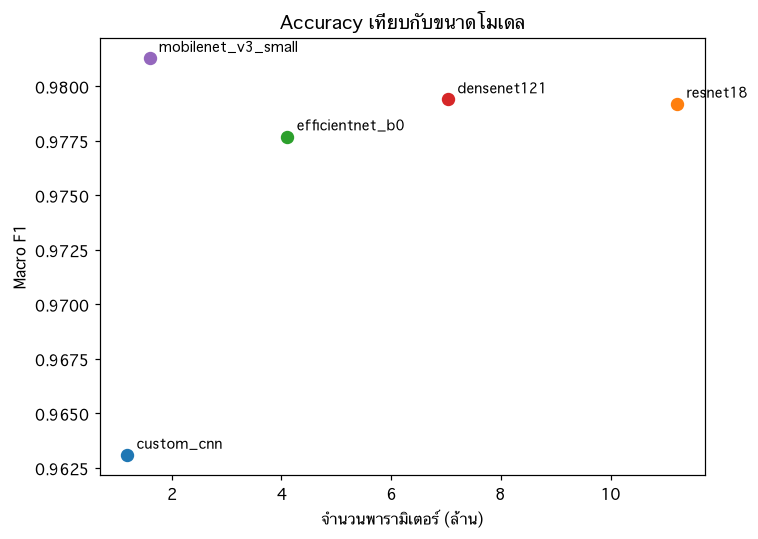

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for r in rows:
    ax.scatter(float(r["params_m"]), float(r["macro_f1"]), s=60)
    ax.annotate(r["model"], (float(r["params_m"]), float(r["macro_f1"])),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("จำนวนพารามิเตอร์ (ล้าน)"); ax.set_ylabel("Macro F1")
ax.set_title("Accuracy เทียบกับขนาดโมเดล")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "figures" / "model_comparison.png", bbox_inches="tight")
plt.show()

### เลือกโมเดลอย่างไร

ดู **Macro F1** เป็นหลัก ไม่ใช่ accuracy เพราะข้อมูลไม่สมดุล
ถ้าสองโมเดลใกล้กัน ให้เลือกตัวที่เล็กกว่า/เร็วกว่า

เมื่อเลือกได้แล้ว แก้ `model:` ใน `configs/augmentation.yaml` และ `configs/generalization.yaml`
แล้วไปที่ `03_augmentation.ipynb`